## HW 7

In [8]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [9]:
import os
import requests
import zipfile

url = "https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/SpamEmailClassificationDataset.zip?raw=true"
zip_file_path = "SpamEmailClassificationDataset.zip"
csv_file_name = "combined_data.csv"

if not os.path.exists(csv_file_name):
    response = requests.get(url) 
    
    with open(zip_file_path, 'wb') as f:
        f.write(response.content)
        
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall('.')
    os.remove(zip_file_path)

In [10]:
import pandas as pd
df_file_path = os.path.join('./SpamEmailClassificationDataset/', csv_file_name)
df = pd.read_csv(df_file_path)
print(f"Shape: {df.shape}")
print(df.head(10))
print(df.info())

Shape: (14861, 2)
   label                                               text
0  label                                               text
1      1  ounce feather bowl hummingbird opec moment ala...
2      1  wulvob get your medircations online qnb ikud v...
3      0   computer connection from cnn com wednesday es...
4      1  university degree obtain a prosperous future m...
5      0  thanks for all your answers guys i know i shou...
6      0  larry king live at escapenumber escapenumber p...
7      0  michael pobega wrote i'm not sure if it's the ...
8      0  hi i have this error tr sample escapenumber es...
9      1  works gateway world art explore tattooing full...
<class 'pandas.DataFrame'>
RangeIndex: 14861 entries, 0 to 14860
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   14861 non-null  str  
 1   text    14861 non-null  str  
dtypes: str(2)
memory usage: 232.3 KB
None


### Splitting the dataset

In [11]:
# Filter by label + get samples 
df_spam = df[df['label'] == '1'].sample(n=1500, random_state=42)
df_ham = df[df['label'] == '0'].sample(n=1500, random_state=42)

#  Merge datasets
df_sliced = pd.concat([df_spam, df_ham])

# Mixing records back
df_sliced = df_sliced.sample(frac=1, random_state=42).reset_index(drop=True)
df_sliced

,label,text
0,0,dave will continue to have the friday afternoo...
1,1,need in software for your pc ? just visit our ...
2,0,on escapenumber escapenumber escapenumber arne...
3,1,if this is your wife then it is already too la...
4,0,hello everyone i want to calculate an instrume...
...,...,...
2995,0,begin pgp signed message hash shaescapenumber...
2996,1,lese selbst :\neu - abgeordnete goennen sich l...
2997,1,flame may month look may black some responsibl...
2998,1,if you cannot adequately view this message ple...


### Distribution Visualization

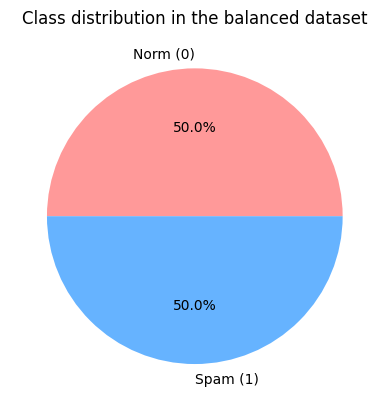

In [12]:
import matplotlib.pyplot as plt

df_sliced['label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    colors=['#ff9999', '#66b3ff'], 
    labels=['Norm (0)', 'Spam (1)'] 
)

plt.title("Class distribution in the balanced dataset")
plt.show()

### Preprosessing

In [13]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/elizabethsheremet/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/elizabethsheremet/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/elizabethsheremet/nltk_data...


True

In [14]:
corpus = []
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

for document in df_sliced["text"]:
    # text to lowercase
    text = str(document).lower()
    # tokenization
    tokens = word_tokenize(text) 
    
    clean_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word.isalpha() and word not in stop_words
    ]

    corpus.append(" ".join(set(clean_tokens)))

df_sliced["text"] = corpus

print(df_sliced.head(5))

  label                                               text
0     0  april afternoon meeting bev one dave conflict ...
1     1  might pc software site best regard shery need ...
2     0  hard high fully nz p want differen third arne ...
3     1  marriage solely http sender informa copying de...
4     0  http reproducible exclude want get störger mat...


### Train/Test Split


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_sliced['text'],
    df_sliced['label'],
    test_size = 0.2,
    random_state=42,
    stratify=df_sliced['label']
)

train_spam = X_train[y_train == '1'].tolist()
train_ham = X_train[y_train == '0'].tolist()

test_emails = X_test.tolist()
test_labels = y_test.tolist()

print(f"Train spam: {len(train_spam)}. Train ham: {len(train_ham)}")
print(f"Test emails: {len(test_emails)}. Test labels: {len(test_labels)}")


Train spam: 1200. Train ham: 1200
Test emails: 600. Test labels: 600


### Train

In [16]:
#  Count words in spam/ham emails to find the most frequent ones
def get_word_frequencies(email_list):
    freq_dict = {}
    
    for e in email_list:
        words = e.split()
        for w in words:
            freq_dict[w] = freq_dict.get(w, 0) + 1
    return freq_dict

spam_counts = get_word_frequencies(train_spam)
ham_counts = get_word_frequencies(train_ham)

In [17]:
# Base Probabilities
prob_spam = len(train_spam)/ (len(train_spam) + len(train_ham))
prob_ham = len(train_ham)/ (len(train_spam) + len(train_ham))

print(f"Base Probability Spam: {prob_spam}")
print(f"Base Probability Ham: {prob_ham}")

Base Probability Spam: 0.5
Base Probability Ham: 0.5


In [18]:
# Probability Dictionaries
dict_spamicity = {word: (count + 1) / (len(train_spam) + 2) for word, count in spam_counts.items()}
dict_hamicity = {word: (count + 1) / (len(train_ham) + 2) for word, count in ham_counts.items()}

#### Bayes function

In [19]:
from math import log, exp

def mult_log(probs):
    return sum([log(p) for p in probs if p > 0])

def Bayes(email, prob_spam, prob_ham, dict_spamicity, dict_hamicity, total_spam, total_ham):
    probs_s = []
    probs_h = []

    for word in email:
        try:
            pr_WS = dict_spamicity[word]  
        except KeyError:
            pr_WS = 1 / max(1, total_spam + 2)  

        try:
            pr_WH = dict_hamicity[word]  
        except KeyError:
            pr_WH = 1 / max(1, total_ham + 2)  

        probs_s.append(pr_WS)
        probs_h.append(pr_WH)

    log_P_S = log(prob_spam) + mult_log(probs_s)
    log_P_H = log(prob_ham) + mult_log(probs_h)

    if log_P_S > log_P_H:
        return 1 # SPAM
    else:
        return 0 # HAM


### Test

In [20]:
correct_predictions = 0

for i in range(len(test_emails)):
    email_words = test_emails[i].split()
    
    prediction = Bayes(
        email_words, 
        prob_spam, 
        prob_ham, 
        dict_spamicity, 
        dict_hamicity, 
        len(train_spam), 
        len(train_ham)
    )
    
    # Comparison
    if str(prediction) == str(test_labels[i]):
        correct_predictions += 1

accuracy = correct_predictions / len(test_emails)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 87.67%


### Conslusion


In [21]:
# Sort probability dict
top_spam_words = sorted(dict_spamicity.items(), key=lambda item: item[1], reverse=True)

# Top-15 SPAM
print("Top 15 SPAM words:")
for word, prob in top_spam_words[:15]:
    print(f"Word: '{word:<15}' | Probability: {prob:.4f}")

Top 15 SPAM words:
Word: 'escapenumber   ' | Probability: 0.4659
Word: 'http           ' | Probability: 0.3952
Word: 'com            ' | Probability: 0.2895
Word: 'one            ' | Probability: 0.2604
Word: 'price          ' | Probability: 0.2596
Word: 'u              ' | Probability: 0.2512
Word: 'day            ' | Probability: 0.2188
Word: 'time           ' | Probability: 0.2138
Word: 'please         ' | Probability: 0.1889
Word: 'get            ' | Probability: 0.1805
Word: 'like           ' | Probability: 0.1772
Word: 'new            ' | Probability: 0.1755
Word: 'escapelong     ' | Probability: 0.1747
Word: 'offer          ' | Probability: 0.1705
Word: 'www            ' | Probability: 0.1664


A Naive Bayes classifier was successfully implemented to categorize emails into Spam and Ham. 
Pipelin: applying preprocessing (tokenization, stop-word removal, lemmatization) before splitting the dataset. To ensure mathematical stability during inference, the algorithm was optimized using logarithmic probabilities, and Laplace smoothing was applied to handle out-of-vocabulary terms.

Analyzing the final probability distributions indicates clear signs of spam. The most noticable marker is the `escapenumber` (present in ~46.6% of spam emails), highlighting the model's sensitivity to masked numerical data(phones, amounts of miney, etc). 

Additionally, URL components `(http, com, www)` strongly indicate on redirecting users to external resources. 
Classic social triggers `(price, offer, new)` arerecognized by the algorithm. 

Overall, the model demonstrates a solid understanding of text-based spam indicators with accuracy $87.67 \%$